# Week 11


# Lecture 18: Gradient Boosting and XGBoost

We previously discussed boosting and AdaBoost, a powerful ensemble method for classification or regression.

This week, we will learn about another variation of boosting: **gradient boosting** and the **XGBoost** algorithm, currently one of the best classifiers for many problems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn

from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_wine
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import cifar10

I0000 00:00:1786766993.507977   42901 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Let's try gradient boosting.

      Iter       Train Loss   Remaining Time 
         1           1.8954            6.83m
         2           1.6553            6.96m
         3           1.4853            8.78m
         4           1.3380           10.01m
         5           1.2214            9.67m
         6           1.1168            9.55m
         7           1.0328            9.18m
         8           0.9632            8.74m
         9           0.8937            8.35m
        10           0.8365            8.04m
        20           0.4927            6.46m
        30           0.3407            5.43m
        40           0.2589            4.49m
        50           0.2059            3.69m
        60           0.1684            2.91m
        70           0.1409            2.16m
        80           0.1203            1.43m
        90           0.1027           42.83s
       100           0.0888            0.00s

Training Classification Report:

               precision    recall  f1-score   support

         

<Figure size 640x480 with 0 Axes>

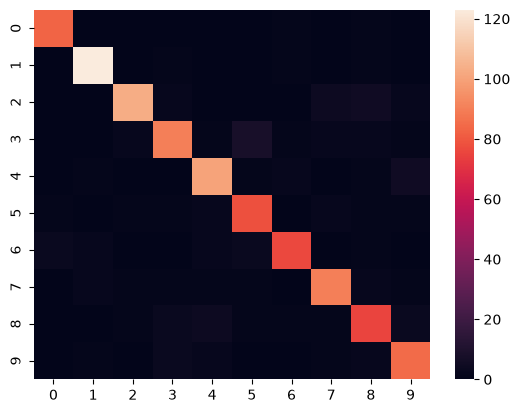

<Figure size 640x480 with 0 Axes>

In [2]:
(trainX, trainY), (testX, testY) = mnist.load_data()

trainX = trainX[:10000]
trainY = trainY[:10000]

testX = testX[:1000]
testY = testY[:1000]

# preprocess the data
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2])
trainX = trainX.astype('float')/255.0

testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2])
testX = testX.astype('float')/255.0

# build the classifier
model = GradientBoostingClassifier(verbose = 1)

# fit the classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

Note that we ran with a training set of just 10,000 images because gradient boosting is incapable of parallelization and is, therefore, rather slow.

Let's also try the `HistGradientBoostingClassifier`, an implementation of an algorithm similar to ordinary `GradientBoostingClassifier` but it sometimes runs much faster on large datasets. It is a `scikit-learn` implementation based on Microsoft's [Light GBM](https://github.com/Microsoft/LightGBM).

Binning 0.339 GB of training data: 1.662 s
Binning 0.038 GB of validation data: 0.032 s
Fitting gradient boosted rounds:
Fit 1000 trees in 163.430 s, (31000 total leaves)
Time spent computing histograms: 142.996s
Time spent finding best splits:  12.239s
Time spent applying splits:      4.378s
Time spent predicting:           0.202s

Training Classification Report:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5923
           1       1.00      1.00      1.00      6742
           2       1.00      1.00      1.00      5958
           3       1.00      1.00      1.00      6131
           4       1.00      1.00      1.00      5842
           5       1.00      1.00      1.00      5421
           6       1.00      1.00      1.00      5918
           7       1.00      1.00      1.00      6265
           8       1.00      1.00      1.00      5851
           9       1.00      1.00      1.00      5949

    accuracy                       

<Figure size 640x480 with 0 Axes>

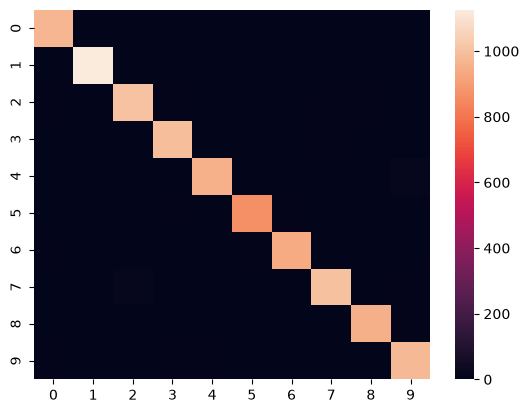

<Figure size 640x480 with 0 Axes>

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier

(trainX, trainY), (testX, testY) = mnist.load_data()

# preprocess the data
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2])
trainX = trainX.astype('float')/255.0

testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2])
testX = testX.astype('float')/255.0

# build the classifier
model = HistGradientBoostingClassifier(verbose = 1)

# fit the classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

This method runs way faster and has better accuracy.

## CIFAR-10 Examples

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

(trainX, trainY), (testX, testY) = cifar10.load_data()

# preprocess the data
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2] * 3)
trainX = trainX.astype('float')/255.0

testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2] * 3)
testX = testX.astype('float')/255.0

# build the classifier
model = ExtraTreesClassifier(verbose = 2, n_jobs = -1)

# fit the classifier to the training data
model.fit(trainX, trainY.ravel())

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
 93454336/170498071 ━━━━━━━━━━━━━━━━━━━━ 6:49 5us/step

### Breast Cancer Classification

In [ ]:
from xgboost import XGBClassifier

[23:21:13] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[0]	validation_0-logloss:0.45594
[1]	validation_0-logloss:0.33100
[2]	validation_0-logloss:0.25211
[3]	validation_0-logloss:0.19699
[4]	validation_0-logloss:0.15478
[5]	validation_0-logloss:0.12618
[6]	validation_0-logloss:0.10818
[7]	validation_0-logloss:0.09551
[8]	validation_0-logloss:0.08214
[9]	validation_0-logloss:0.07518
[10]	validation_0-logloss:0.06873
[11]	validation_0-logloss:0.06348
[12]	validation_0-logloss:0.05953
[13]	validation_0-logloss:0.05945
[14]	validation_0-logloss:0.05552
[15]	validation_0-logloss:0.05261
[16]	validation_0-logloss:0.05027
[17]	validation_0-logloss:0.05126
[18]	validation_0-logloss:0.05253
[19]	validation_0-logloss:0.05111
[20]	validation_0-lo

<Figure size 432x288 with 0 Axes>

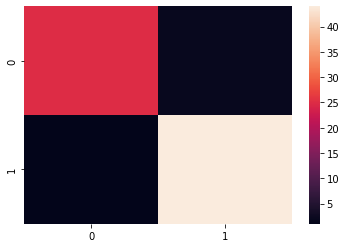

<Figure size 432x288 with 0 Axes>

In [ ]:
cancer = load_breast_cancer()

X = cancer['data']
Y = cancer['target']

# split the data into train and test sets
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)
valX, testX, valY, testY = train_test_split(testX, testY, test_size = 0.5)

# build the classifier
model = XGBClassifier(n_jobs = -1)

# fit the classifier to the training data
model.fit(trainX, trainY, eval_set = [(valX, valY)])

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metricsl
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

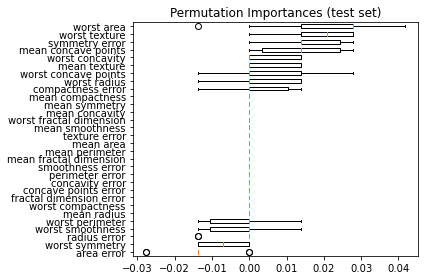

In [ ]:
result = permutation_importance(model, testX, testY, n_repeats = 10, n_jobs = -1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, vert = False,
           labels = cancer.feature_names[sorted_idx])
ax.set_title("Permutation Importances (test set)")
fig.tight_layout()
plt.show()

### Wine Example

[23:22:04] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[0]	validation_0-mlogloss:0.89066
[1]	validation_0-mlogloss:0.69186
[2]	validation_0-mlogloss:0.58930
[3]	validation_0-mlogloss:0.52835
[4]	validation_0-mlogloss:0.45808
[5]	validation_0-mlogloss:0.38577
[6]	validation_0-mlogloss:0.33619
[7]	validation_0-mlogloss:0.30202
[8]	validation_0-mlogloss:0.29147
[9]	validation_0-mlogloss:0.24931
[10]	validation_0-mlogloss:0.22095
[11]	validation_0-mlogloss:0.20778
[12]	validation_0-mlogloss:0.18805
[13]	validation_0-mlogloss:0.18118
[14]	validation_0-mlogloss:0.16026
[15]	validation_0-mlogloss:0.16059
[16]	validation_0-mlogloss:0.15153
[17]	validation_0-mlogloss:0.13565
[18]	validation_0-mlogloss:0.13367
[19]	validation_0-mlogloss:0.12542

C:\Users\Ryan\miniconda3\envs\DL\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


<Figure size 432x288 with 0 Axes>

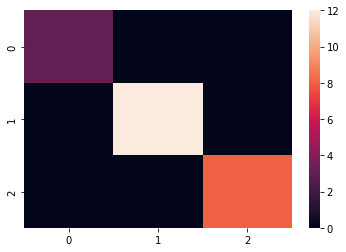

<Figure size 432x288 with 0 Axes>

In [ ]:
wine = load_wine()

X = wine['data']
Y = wine['target']

# split the data into train and test sets
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)
valX, testX, valY, testY = train_test_split(testX, testY, test_size = 0.5)

# build the classifier
model = XGBClassifier(n_jobs = -1)

# fit the classifier to the training data
model.fit(trainX, trainY, eval_set = [(valX, valY)])

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

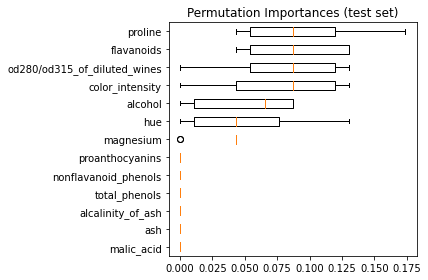

In [ ]:
result = permutation_importance(model, testX, testY, n_repeats = 10, n_jobs = -1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, vert = False,
           labels = np.array(wine.feature_names)[sorted_idx])
ax.set_title("Permutation Importances (test set)")
fig.tight_layout()
plt.show()

### MNIST Example

C:\Users\Ryan\miniconda3\envs\DL\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[23:22:41] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[0]	validation_0-mlogloss:1.37077
[1]	validation_0-mlogloss:1.05099
[2]	validation_0-mlogloss:0.84082
[3]	validation_0-mlogloss:0.69238
[4]	validation_0-mlogloss:0.58026
[5]	validation_0-mlogloss:0.49551
[6]	validation_0-mlogloss:0.43004
[7]	validation_0-mlogloss:0.37868
[8]	validation_0-mlogloss:0.33703
[9]	validation_0-mlogloss:0.30279
[10]	validation_0-mlogloss:0.27499
[11]	validation_0-mlogloss:0.25283
[12]	validation_0-mlogloss:0.23451
[13]	validation_0-mlogloss:0.21916
[14]	validation_0-mlogloss:0.20493
[15]	validation_0-mlogloss:0.19385
[16]	validation_0-mlogloss:0.18388
[17]	validation_0-mlogloss:0.17608
[18]	validation_0-mlogloss:0.16811
[19]	validation_0-mlogloss:0.16050

<Figure size 432x288 with 0 Axes>

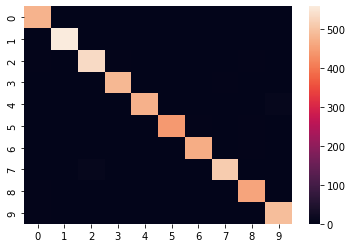

<Figure size 432x288 with 0 Axes>

In [ ]:
(trainX, trainY), (testX, testY) = mnist.load_data()

# preprocess the data
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2])
trainX = trainX.astype('float')/255.0

testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2])
testX = testX.astype('float')/255.0

valX, testX, valY, testY = train_test_split(testX, testY, test_size = 0.5)

# build the classifier
model = XGBClassifier(n_jobs = -1)

# fit the classifier to the training data
model.fit(trainX, trainY, eval_set = [(valX, valY)])

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

Let's try to tune XGBoost with 5-fold cross-validation to see if we can improve the results.

C:\Users\Ryan\miniconda3\envs\DL\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[23:23:53] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[0]	validation_0-mlogloss:1.37077
[1]	validation_0-mlogloss:1.05099
[2]	validation_0-mlogloss:0.84082
[3]	validation_0-mlogloss:0.69238
[4]	validation_0-mlogloss:0.58026
[5]	validation_0-mlogloss:0.49551
[6]	validation_0-mlogloss:0.43004
[7]	validation_0-mlogloss:0.37868
[8]	validation_0-mlogloss:0.33703
[9]	validation_0-mlogloss:0.30279
[10]	validation_0-mlogloss:0.27499
[11]	validation_0-mlogloss:0.25283
[12]	validation_0-mlogloss:0.23451
[13]	validation_0-mlogloss:0.21916
[14]	validation_0-mlogloss:0.20493
[15]	validation_0-mlogloss:0.19385
[16]	validation_0-mlogloss:0.18388
[17]	validation_0-mlogloss:0.17608
[18]	validation_0-mlogloss:0.16811
[19]	validation_0-mlogloss:0.16050

<Figure size 432x288 with 0 Axes>

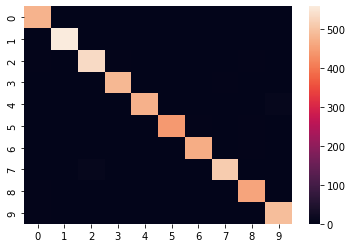

<Figure size 432x288 with 0 Axes>

In [ ]:
parameters = {'max_depth': [1, 5, 10, 100, None], 'reg_lambda': [0.001, 0.01, 0.1, 1, 10]}
model = GridSearchCV(XGBClassifier(n_jobs = -1, eval_metric='mlogloss'), parameters, n_jobs = -1)

# build the classifier
model = XGBClassifier(n_jobs = -1)

# fit the classifier to the training data
model.fit(trainX, trainY, eval_set = [(valX, valY)])

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

So, we tried, but made no gains.

### CIFAR10 Example

[23:25:50] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[0]	validation_0-mlogloss:2.13656
[1]	validation_0-mlogloss:2.03318
[2]	validation_0-mlogloss:1.95227
[3]	validation_0-mlogloss:1.89216
[4]	validation_0-mlogloss:1.83970
[5]	validation_0-mlogloss:1.79876
[6]	validation_0-mlogloss:1.76423
[7]	validation_0-mlogloss:1.73341
[8]	validation_0-mlogloss:1.70854
[9]	validation_0-mlogloss:1.68552
[10]	validation_0-mlogloss:1.66271
[11]	validation_0-mlogloss:1.64533
[12]	validation_0-mlogloss:1.62746
[13]	validation_0-mlogloss:1.61124
[14]	validation_0-mlogloss:1.59772
[15]	validation_0-mlogloss:1.58506
[16]	validation_0-mlogloss:1.57178
[17]	validation_0-mlogloss:1.56225
[18]	validation_0-mlogloss:1.55158
[19]	validation_0-mlogloss:1.54190

<Figure size 432x288 with 0 Axes>

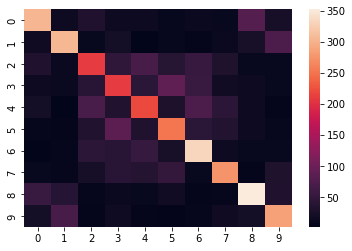

<Figure size 432x288 with 0 Axes>

In [ ]:
(trainX, trainY), (testX, testY) = cifar10.load_data()

# preprocess the data
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2] * 3)
trainX = trainX.astype('float')/255.0

testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2] * 3)
testX = testX.astype('float')/255.0

valX, testX, valY, testY = train_test_split(testX, testY, test_size = 0.5)

# build the classifier
model = XGBClassifier(n_jobs = -1)

# fit the classifier to the training data
model.fit(trainX, trainY.ravel(), eval_set = [(valX, valY.ravel())])

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

[23:30:51] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[0]	validation_0-mlogloss:2.13656
[1]	validation_0-mlogloss:2.03318
[2]	validation_0-mlogloss:1.95227
[3]	validation_0-mlogloss:1.89216
[4]	validation_0-mlogloss:1.83970
[5]	validation_0-mlogloss:1.79876
[6]	validation_0-mlogloss:1.76423
[7]	validation_0-mlogloss:1.73341
[8]	validation_0-mlogloss:1.70854
[9]	validation_0-mlogloss:1.68552
[10]	validation_0-mlogloss:1.66271
[11]	validation_0-mlogloss:1.64533
[12]	validation_0-mlogloss:1.62746
[13]	validation_0-mlogloss:1.61124
[14]	validation_0-mlogloss:1.59772
[15]	validation_0-mlogloss:1.58506
[16]	validation_0-mlogloss:1.57178
[17]	validation_0-mlogloss:1.56225
[18]	validation_0-mlogloss:1.55158
[19]	validation_0-mlogloss:1.54190

<Figure size 432x288 with 0 Axes>

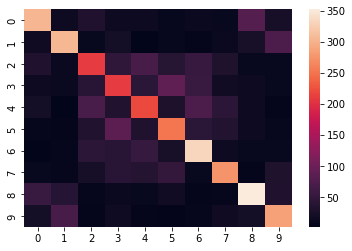

<Figure size 432x288 with 0 Axes>

In [ ]:
parameters = {'max_depth': [1, 5, 10, 100, None], 'reg_lambda': [0.001, 0.01, 0.1, 1, 10]}

model = GridSearchCV(XGBClassifier(n_jobs = -1, eval_metric='mlogloss'), parameters, n_jobs = -1)

# build the classifier
model = XGBClassifier(n_jobs = -1)

# fit the classifier to the training data
model.fit(trainX, trainY.ravel(), eval_set = [(valX, valY.ravel())])

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

# Lecture 19: Supervised Learning Review and Model Selection

Lecture materials will be added before this class meeting.
